In [1]:
import pickle

# SVD (main folder)
with open(r"C:\Users\praneeth\OneDrive\Vaishnavi maam pe\svd_results.pkl", "rb") as f:
    results_svd, N_svd = pickle.load(f)

# CHEB (inside codes folder)
with open(r"C:\Users\praneeth\OneDrive\Vaishnavi maam pe\codes\cheb_results.pkl", "rb") as f:
    results_cheb, N_cheb = pickle.load(f)

In [2]:
print(type(results_svd))
print(type(results_cheb))

print(len(N_svd), len(N_cheb))

<class 'dict'>
<class 'dict'>
6 9


In [3]:
r"C:\Users\praneeth\OneDrive\Vaishnavi maam pe\svd_results.pkl"
r"C:\Users\praneeth\OneDrive\Vaishnavi maam pe\codes\cheb_results.pkl"

'C:\\Users\\praneeth\\OneDrive\\Vaishnavi maam pe\\codes\\cheb_results.pkl'

In [4]:
print(results_svd.keys())
print(results_cheb.keys())

dict_keys(['dense', 'hodlr'])
dict_keys(['dense', 'hodlr'])


In [5]:
print(len(results_svd['dense']))
print(len(results_cheb['hodlr']))

6
3


In [6]:
print(results_svd['dense'][0].keys())

dict_keys(['method', 'rank_k', 'min_block', 'J_final', 'J_initial', 'total_time', 'total_gradient_descent_time', 'total_hodlr_construction_time', 'timing', 'J_hist', 't_hist', 'grad_norm_hist', 'eta_hist', 'convergence', 'h_stats'])


In [7]:
print(results_cheb['hodlr']['p12'][0].keys())

dict_keys(['method', 'p', 'min_block', 'J_final', 'J_initial', 'total_time', 'time_build', 'time_ops', 'iterations', 'final_grad_norm', 'J_hist', 't_hist', 'grad_norm_hist', 'h_stats'])


In [8]:
gd_dense = []
gd_svd = []
gd_cheb = []

# ===== Dense + SVD =====
for i in range(len(N_svd)):
    m_dense = results_svd['dense'][i]
    m_svd   = results_svd['hodlr']['r15'][i]

    if m_dense is not None:
        gd_dense.append(m_dense['total_gradient_descent_time'])
        gd_svd.append(m_svd['total_gradient_descent_time'])

# ===== Chebyshev =====
for i in range(len(N_cheb)):
    m_cheb = results_cheb['hodlr']['p12'][i]
    gd_cheb.append(m_cheb['time_ops'])

In [9]:
print(len(gd_dense), len(gd_svd), len(gd_cheb))

6 6 9


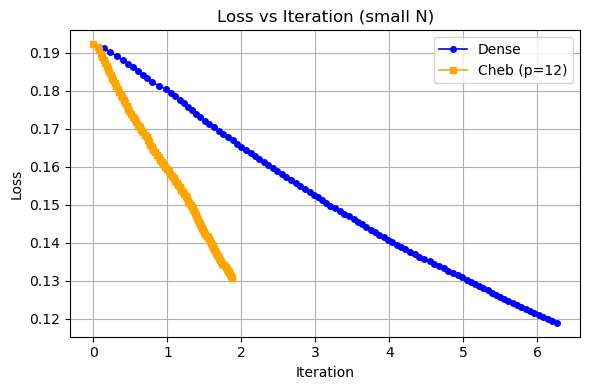

In [29]:
import matplotlib.pyplot as plt

# ===== Choose SMALL N =====
i = 0  

dense = results_svd['dense'][i]
cheb = results_cheb['hodlr']['p12'][i]

# ===== Extract Dense =====
iter_dense = dense['t_hist']
loss_dense = dense['J_hist']

# ===== Extract Cheb =====
iter_cheb = cheb['t_hist']

if 'J_hist' in cheb:
    loss_cheb = cheb['J_hist']
elif 'j_hist' in cheb:
    loss_cheb = cheb['j_hist']
else:
    raise ValueError("No loss history found in Cheb data")

# ===== Plot =====
plt.figure(figsize=(6,4))

plt.plot(iter_dense, loss_dense,
         marker='o', linestyle='-',
         linewidth=1.2, markersize=4,
         label="Dense", color='blue')

plt.plot(iter_cheb, loss_cheb,
         marker='s', linestyle='-',
         linewidth=1.2, markersize=4,
         label="Cheb (p=12)", color='orange')

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss vs Iteration (small N)")

plt.legend()
plt.grid()
plt.tight_layout()

plt.savefig("Figure_6_Loss_SmallN.png", dpi=300)
plt.show()

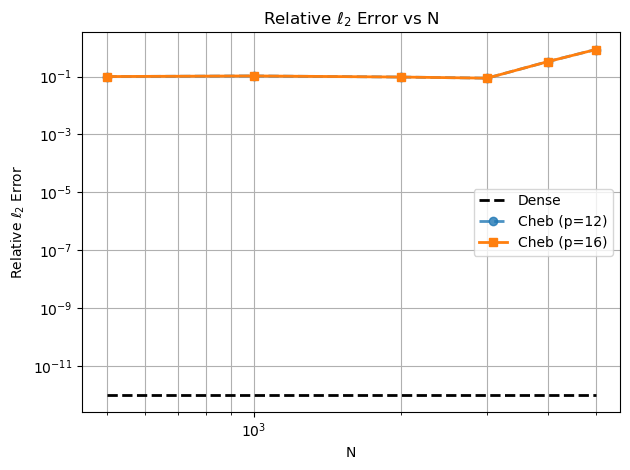

In [22]:
import numpy as np
import matplotlib.pyplot as plt

N_vals = []
err_dense = []
err_p12 = []
err_p16 = []

# Use minimum length to avoid index error
n_points = min(len(results_svd['dense']),
               len(results_cheb['hodlr']['p12']),
               len(results_cheb['hodlr']['p16']))

for i in range(n_points):

    # Extract values
    dense = results_svd['dense'][i]
    cheb12 = results_cheb['hodlr']['p12'][i]
    cheb16 = results_cheb['hodlr']['p16'][i]

    J_dense = dense['J_final']
    J_p12 = cheb12['J_final']
    J_p16 = cheb16['J_final']

    # Compute relative L2 error
    e12 = abs(J_p12 - J_dense) / abs(J_dense)
    e16 = abs(J_p16 - J_dense) / abs(J_dense)

    # Store
    N_vals.append(N_svd[i])   # use same N indexing
    err_dense.append(0.0)     # dense vs dense = 0
    err_p12.append(e12)
    err_p16.append(e16)

# Convert
N_vals = np.array(N_vals)
err_dense = np.array(err_dense)
err_p12 = np.array(err_p12)
err_p16 = np.array(err_p16)

#plt.figure(figsize=(6,4))

# Dense (visible baseline)
plt.plot(N_vals, [1e-12]*len(N_vals), 'k--', linewidth=2, label="Dense")

# Chebyshev
plt.plot(N_vals, err_p12, 'o--', linewidth=2, markersize=6,
         label="Cheb (p=12)", alpha=0.8)

plt.plot(N_vals, err_p16, 's-', linewidth=2, markersize=6,
         label="Cheb (p=16)")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("N")
plt.ylabel("Relative $\\ell_2$ Error")
plt.title("Relative $\\ell_2$ Error vs N")

plt.legend()
plt.grid(True, which='both')
plt.tight_layout()

plt.show()

In [25]:
print("Dense:", t_dense)
print("SVD:", t_svd)

Dense: 332.8233590000309
SVD: 499.9860829000827


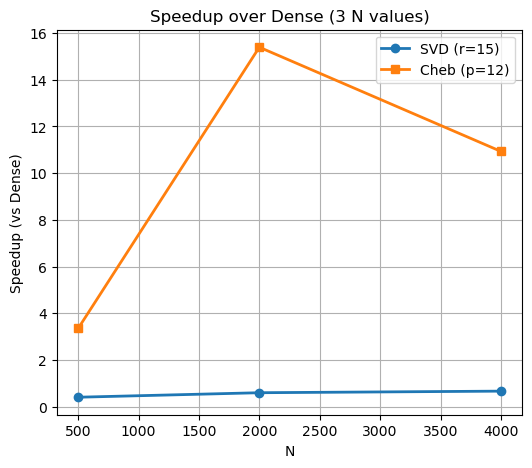

In [24]:
import matplotlib.pyplot as plt

# ===== SELECT EXACTLY 3 N VALUES =====
# choose any 3 valid indices
idx = [0, 2, 4]

N_vals = []
speedup_svd = []
speedup_cheb = []

for i in idx:
    # ----- Extract results -----
    dense = results_svd['dense'][i]
    svd   = results_svd['hodlr']['r15'][i]      # SAME r
    cheb  = results_cheb['hodlr']['p12'][i]     # SAME p

    # ----- N values -----
    N_vals.append(N_svd[i])

    # ----- Times -----
    t_dense = dense['total_time']
    t_svd   = svd['total_time']
    t_cheb  = cheb['total_time']

    # ----- SPEEDUP (IMPORTANT: dense / method) -----
    speedup_svd.append(t_dense / t_svd)
    speedup_cheb.append(t_dense / t_cheb)

# ===== PLOT =====
plt.figure(figsize=(6,5))

plt.plot(N_vals, speedup_svd, 'o-', linewidth=2, label='SVD (r=15)')
plt.plot(N_vals, speedup_cheb, 's-', linewidth=2, label='Cheb (p=12)')

plt.xlabel('N')
plt.ylabel('Speedup (vs Dense)')
plt.title('Speedup over Dense (3 N values)')

plt.legend()
plt.grid(True)

plt.savefig('fig5_speedup_correct.png', dpi=300)
plt.show()

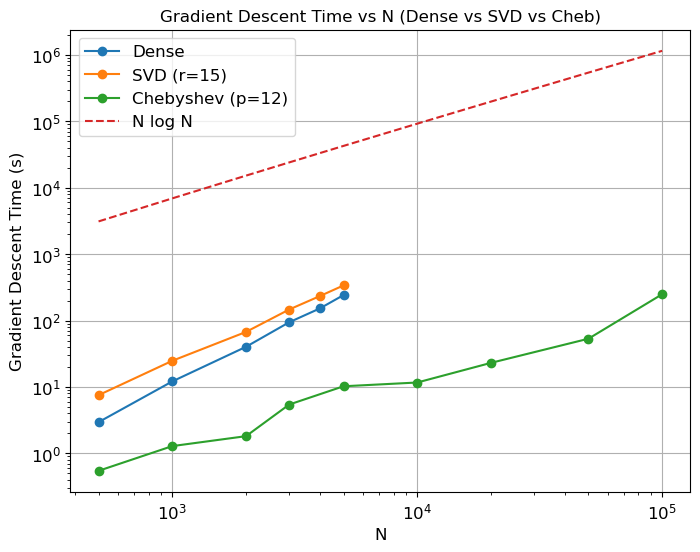

In [40]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

# Dense + SVD
plt.loglog(N_svd[:len(gd_dense)], gd_dense, 'o-', label='Dense')
plt.loglog(N_svd[:len(gd_svd)], gd_svd, 'o-', label='SVD (r=15)')

# Cheb
plt.loglog(N_cheb, gd_cheb, 'o-', label='Chebyshev (p=12)')

# N log N
N_ref = np.array(N_cheb)
plt.loglog(N_ref, N_ref*np.log(N_ref), '--', label='N log N')

plt.xlabel('N')
plt.ylabel('Gradient Descent Time (s)')
plt.title('Gradient Descent Time vs N (Dense vs SVD vs Cheb)')
plt.legend()
plt.grid(True)

plt.savefig("gd_time_combined.png", dpi=300, bbox_inches='tight')
plt.show()

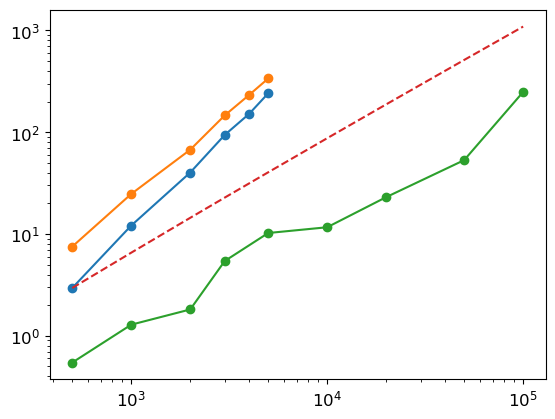

In [42]:
plt.loglog(N_svd[:len(gd_dense)], gd_dense, 'o-', label='Dense')
plt.loglog(N_svd[:len(gd_svd)], gd_svd, 'o-', label='SVD')
plt.loglog(N_cheb, gd_cheb, 'o-', label='Cheb')

plt.loglog(N_ref, (N_ref*np.log(N_ref)) / (N_ref[0]*np.log(N_ref[0])) * gd_dense[0], '--', label='N log N')

In [21]:
for k in results_cheb['hodlr']:
    print(k, len(results_cheb['hodlr'][k]))

p8 9
p12 9
p16 9


In [22]:
print(results_svd.keys())
print(results_cheb.keys())

dict_keys(['dense', 'hodlr'])
dict_keys(['dense', 'hodlr'])


In [23]:
print(results_cheb['hodlr']['p12'][0].keys())

dict_keys(['method', 'p', 'min_block', 'J_final', 'J_initial', 'total_time', 'time_build', 'time_ops', 'iterations', 'final_grad_norm', 'J_hist', 't_hist', 'grad_norm_hist', 'h_stats'])


In [26]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# =========================================================
# FIGURE 3 — TOTAL KDE TIME
# =========================================================
def fig3_combined(results_svd, results_cheb, N_svd, N_cheb):

    plt.figure(figsize=(6,5))

    # Dense
    dense_times = [m['total_time'] for m in results_svd['dense']]
    plt.loglog(N_svd, dense_times, 'o-', label='Dense')

    # SVD
    svd_times = [m['total_time'] for m in results_svd['hodlr']['r15']]
    plt.loglog(N_svd, svd_times, 'o-', label='SVD (r15)')

    # Cheb
    cheb_times = [m['total_time'] for m in results_cheb['hodlr']['p12']]
    plt.loglog(N_cheb, cheb_times, 'o-', label='Cheb (p12)')

    # N log N (use consistent range)
    N = np.array(N_cheb)
    plt.loglog(N, N*np.log(N), '--', label='N log N')

    plt.xlabel('N')
    plt.ylabel('Total Time (s)')
    plt.title('Total KDE Time (Dense vs SVD vs Cheb)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("fig3_combined.png", dpi=300, bbox_inches='tight')
    plt.show()


# =========================================================
# FIGURE 4 — GRADIENT DESCENT TIME (FIXED)
# =========================================================
def fig4_combined(results_svd, results_cheb, N_svd, N_cheb):

    plt.figure(figsize=(6,5))

    # Dense (true GD time)
    dense_vals = [m['total_gradient_descent_time'] for m in results_svd['dense']]
    plt.loglog(N_svd, dense_vals, 'o-', label='Dense')

    # Cheb (safe + correct metric)
    cheb_vals = []
    cheb_N = []

    for i, m in enumerate(results_cheb['hodlr']['p12']):
        if m is not None:
            gd = m.get('total_gradient_descent_time', None)
            if gd is None:
                gd = m.get('time_ops', None)

            if gd is not None:
                cheb_vals.append(gd)
                cheb_N.append(N_cheb[i])

    plt.loglog(cheb_N, cheb_vals, 'o-', label='Cheb (p12)')

    # N log N
    N = np.array(N_cheb)
    plt.loglog(N, N*np.log(N), '--', label='N log N')

    plt.xlabel('N')
    plt.ylabel('Gradient Descent Time (s)')
    plt.title('Gradient Descent Time (Dense vs Cheb)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("fig4_combined.png", dpi=300, bbox_inches='tight')
    plt.show()


# =========================================================
# FIGURE 5 — SPEEDUP (FINAL)
# =========================================================
def fig5_combined(results_svd, results_cheb, N_svd):

    plt.figure(figsize=(6,5))

    # Pick 3 N values
    idx = [1, 3, 5]   # 1000, 3000, 5000
    N_plot = [N_svd[i] for i in idx]

    dense = [results_svd['dense'][i]['total_time'] for i in idx]

    # SVD speedup
    svd = [results_svd['hodlr']['r15'][i]['total_time'] for i in idx]
    speedup_svd = [dense[i]/svd[i] for i in range(len(idx))]

    # Cheb speedup
    cheb = [results_cheb['hodlr']['p12'][i]['total_time'] for i in idx]
    speedup_cheb = [dense[i]/cheb[i] for i in range(len(idx))]

    plt.plot(N_plot, speedup_svd, 'o-', label='SVD (r15)')
    plt.plot(N_plot, speedup_cheb, 'o-', label='Cheb (p12)')

    plt.xlabel('N')
    plt.ylabel('Speedup')
    plt.title('Speedup over Dense (3 N values)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("fig5_combined.png", dpi=300, bbox_inches='tight')
    plt.show()

Generating Figure 3...


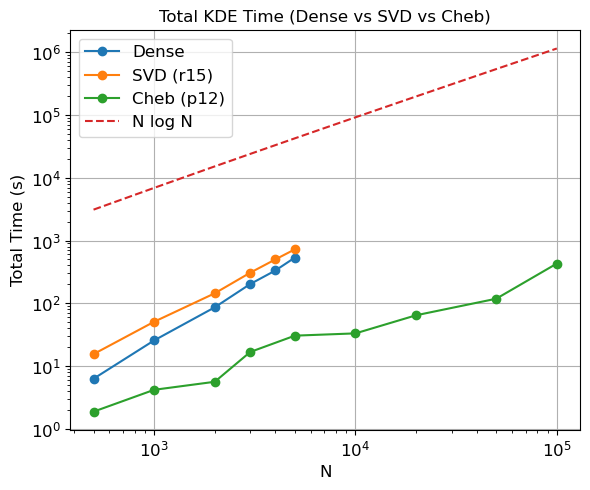

Generating Figure 4...


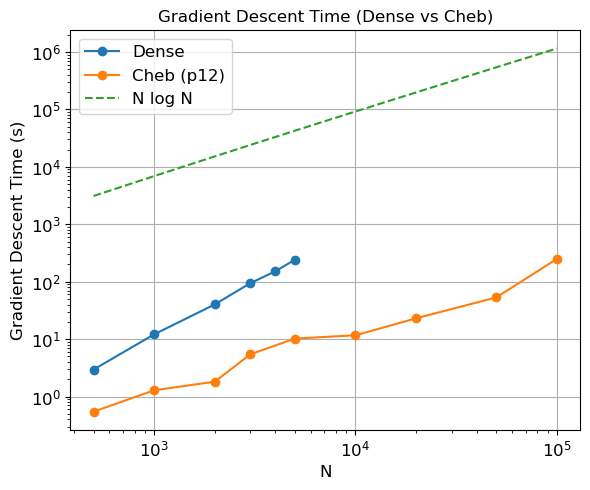

Generating Figure 5...


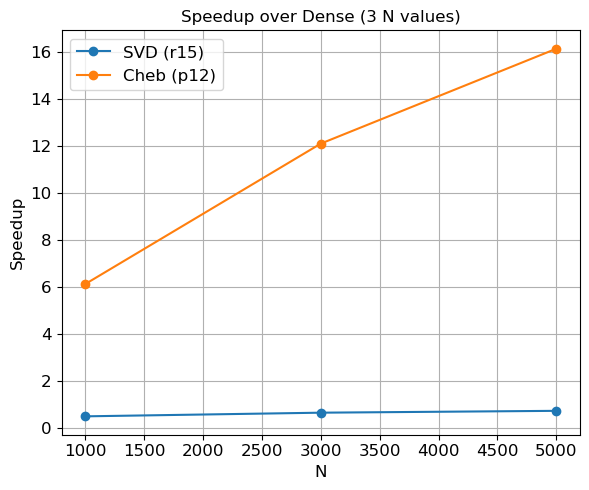


✅ All combined figures generated successfully!
Saved files:
 - fig3_combined.png
 - fig4_combined.png
 - fig5_combined.png


In [27]:
# =========================================================
# RUN ALL COMBINED FIGURES (FINAL)
# =========================================================

# Ensure N alignment (important safety check)
assert len(N_svd) == len(results_svd['dense']), "Mismatch in SVD N and results"
assert 'p12' in results_cheb['hodlr'], "p12 not found in Cheb results"
assert 'r15' in results_svd['hodlr'], "r15 not found in SVD results"

# Use SVD N as reference (common for dense + SVD)
N_values = N_svd

print("Generating Figure 3...")
fig3_combined(results_svd, results_cheb, N_svd, N_cheb)

print("Generating Figure 4...")
fig4_combined(results_svd, results_cheb, N_svd, N_cheb)

print("Generating Figure 5...")
fig5_combined(results_svd, results_cheb, N_svd)

print("\n✅ All combined figures generated successfully!")
print("Saved files:")
print(" - fig3_combined.png")
print(" - fig4_combined.png")
print(" - fig5_combined.png")